<a href="https://colab.research.google.com/github/balakganesh2k3/Intro-to-DL/blob/main/Task_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [27]:
import numpy as np
import matplotlib.pyplot as plt


**3.1 Neural network**

In [17]:
XOR_inputs = np.array([[0, 0],[0, 1],[1, 0],[1, 1]], dtype = float)
XOR_targets = np.array([0, 1, 1, 0], dtype = float)

def sigmoid(x): #activation function
    return 1 / (1 + np.exp(-x))

def sigmoid_derivative(x): #activation function derivative
    s = sigmoid(x)
    return s * (1 - s)

def initialize_weights_standard(weights):
    return weights.standard_normal(9)

def forward(w,x,hidden_activation,output_activation):
    w11, w12, b1, w21, w22, b2, c1, c2, b3 = w
    # Hidden layer
    z1 = w11 * x[0] + w12 * x[1] + b1
    z2 = w21 * x[0] + w22 * x[1] + b2
    h1 = hidden_activation(z1)
    h2 = hidden_activation(z2)
    # Output layer
    z3 = c1 * h1 + c2 * h2 + b3
    y_hat = output_activation(z3)

    return z1, z2, h1, h2, z3, y_hat

**3.2 Error function**


In [28]:
def mse(predictions, targets): #mean sqaured error
    return np.mean((predictions - targets) ** 2)

def get_predictions(w,X,hidden_activation,output_activation):
    predictions = []
    for x in X:
        result = forward(w,x,hidden_activation,output_activation)
        predictions.append(result[-1])
    return np.array(predictions)


def count_misclassified(predictions,targets):
    predicted_labels = (predictions >= 0.5).astype(int)
    return np.sum(predicted_labels != targets)


**3.3 Gradients**

In [29]:
def calculate_gradient(w, X, y, hidden_activation, hidden_derivative, output_activation, output_derivative):

    gradient = np.zeros(9)
    n = len(X)

    for x, target in zip(X, y):
        z1, z2, h1, h2, z3, y_pred = forward(w, x, hidden_activation, output_activation)
        dL_dy = 2 * (y_pred - target) / n
        dy_dz3 = output_derivative(z3)
        delta3 = dL_dy * dy_dz3
        dc1 = delta3 * h1
        dc2 = delta3 * h2
        db3 = delta3
        delta1 = delta3 * w[6] * hidden_derivative(z1)
        delta2 = delta3 * w[7] * hidden_derivative(z2)
        dw11 = delta1 * x[0]
        dw12 = delta1 * x[1]
        db1 = delta1
        dw21 = delta2 * x[0]
        dw22 = delta2 * x[1]
        db2 = delta2

        gradient += np.array([dw11, dw12, db1, dw21, dw22, db2, dc1, dc2, db3])

    return gradient


**3.4 Training and Experimentation**

In [30]:
def train(X, y, initialize_func, hidden_activation, hidden_derivative, learning_rate=0.1, epochs=10000, seed=None, output_activation=sigmoid, output_derivative=sigmoid_derivative, print_every=1000):

    rndm = np.random.default_rng(seed)
    w = initialize_func(rndm)
    initial_weights = w.copy()
    mse_history = []
    misclassified_history = []

    for epoch in range(epochs):

        gradient = calculate_gradient(w, X, y, hidden_activation, hidden_derivative, output_activation, output_derivative)
        w = w - learning_rate * gradient
        predictions = get_predictions(w, X, hidden_activation, output_activation)
        loss = mse(predictions, y)
        errors = count_misclassified(predictions, y)
        mse_history.append(loss)
        misclassified_history.append(errors)
        if print_every > 0 and ((epoch + 1) % print_every == 0 or epoch == 0):
            print("Epoch:", epoch + 1, "| MSE:", loss, "| Misclassified:", errors)

    final_predictions = get_predictions(w, X, hidden_activation, output_activation)

    network = {
        "weights": w.copy(),
        "initial_weights": initial_weights,
        "hidden_activation": hidden_activation,
        "output_activation": output_activation,
        "learning_rate": learning_rate,
        "seed": seed,
        "epochs": epochs,
        "mse_history": mse_history,
        "misclassified_history": misclassified_history,
        "final_predictions": final_predictions
    }

    return network



In [31]:
#Training

network = train(XOR_inputs, XOR_targets, initialize_weights_standard, sigmoid, sigmoid_derivative, learning_rate=0.1, epochs=10000, seed=42, print_every=1000)

print("Trained weights:")
print(network["weights"])

print("\nFinal predictions:")
print(network["final_predictions"])

print("\nPredicted classes:")
print((network["final_predictions"] >= 0.5).astype(int))

print("\nFinal MSE:")
print(network["mse_history"][-1])

print("\nMisclassified inputs:")
print(network["misclassified_history"][-1])

Epoch: 1 | MSE: 0.25299702836211224 | Misclassified: 3
Epoch: 1000 | MSE: 0.24526291641632547 | Misclassified: 2
Epoch: 2000 | MSE: 0.22792591777100507 | Misclassified: 1
Epoch: 3000 | MSE: 0.19170354987606622 | Misclassified: 1
Epoch: 4000 | MSE: 0.1187502610321801 | Misclassified: 0
Epoch: 5000 | MSE: 0.05053542229551137 | Misclassified: 0
Epoch: 6000 | MSE: 0.025403544494427967 | Misclassified: 0
Epoch: 7000 | MSE: 0.01569997583350463 | Misclassified: 0
Epoch: 8000 | MSE: 0.01100567029758934 | Misclassified: 0
Epoch: 9000 | MSE: 0.008339300574118084 | Misclassified: 0
Epoch: 10000 | MSE: 0.006652486039276563 | Misclassified: 0
Trained weights:
[ 4.63800053 -4.46546592  2.23225289  4.96717863 -5.15040641 -2.79655121
 -6.2400418   6.58692836  2.8499684 ]

Final predictions:
[0.08266717 0.90449652 0.92612932 0.07209917]

Predicted classes:
[0 1 1 0]

Final MSE:
0.006652486039276563

Misclassified inputs:
0


Plots

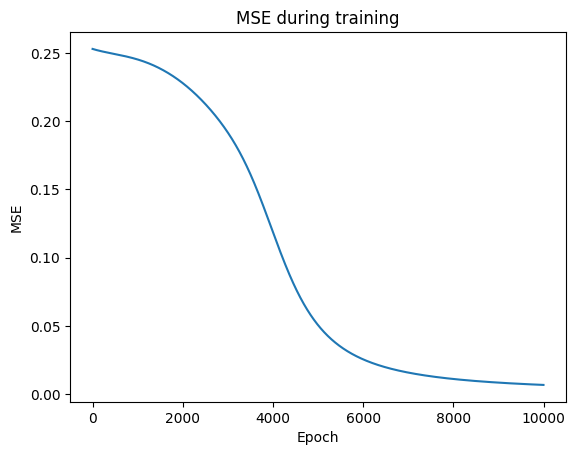

In [32]:
plt.plot(network["mse_history"])
plt.xlabel("Epoch")
plt.ylabel("MSE")
plt.title("MSE during training")
plt.show()

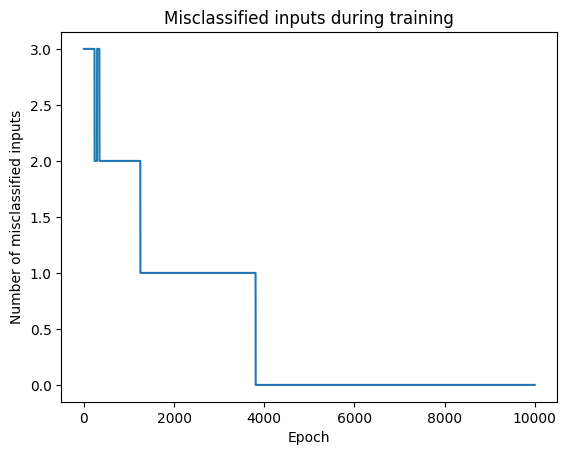

In [33]:
plt.plot(network["misclassified_history"])
plt.xlabel("Epoch")
plt.ylabel("Number of misclassified inputs")
plt.title("Misclassified inputs during training")
plt.show()


In [34]:
def numerical_gradient(w, X, y, hidden_activation, output_activation, epsilon=1e-5):

    numerical_grad = np.zeros_like(w)

    for i in range(len(w)):

        w_plus = w.copy()
        w_minus = w.copy()

        w_plus[i] += epsilon
        w_minus[i] -= epsilon

        predictions_plus = get_predictions(w_plus, X, hidden_activation, output_activation)
        predictions_minus = get_predictions(w_minus, X, hidden_activation, output_activation)

        loss_plus = mse(predictions_plus, y)
        loss_minus = mse(predictions_minus, y)

        numerical_grad[i] = (loss_plus - loss_minus) / (2 * epsilon)

    return numerical_grad

test_rng = np.random.default_rng(0)

test_w = test_rng.standard_normal(9)

analytic_gradient = calculate_gradient(test_w, XOR_inputs, XOR_targets, sigmoid, sigmoid_derivative, sigmoid, sigmoid_derivative)

numerical_grad = numerical_gradient(test_w, XOR_inputs, XOR_targets, sigmoid, sigmoid)

print("\nAnalytical gradient:")
print(analytic_gradient)

print("\nNumerical gradient:")
print(numerical_grad)

print("\nMaximum difference:")
print(np.max(np.abs(analytic_gradient - numerical_grad)))



Analytical gradient:
[0.01213408 0.00875623 0.02090218 0.00978108 0.00743545 0.0167204
 0.04670375 0.03875069 0.07095481]

Numerical gradient:
[0.01213408 0.00875623 0.02090218 0.00978108 0.00743545 0.0167204
 0.04670375 0.03875069 0.07095481]

Maximum difference:
4.827541144614145e-12


Different learning rates

In [35]:
learning_rates = [0.01, 0.05, 0.1, 0.5, 1.0]

learning_rate_results = {}
seeds = range(20)

for learning_rate in learning_rates:
    learning_rate_results[learning_rate] = []
    for seed in seeds:
        network_result = train(XOR_inputs, XOR_targets, initialize_weights_standard, sigmoid, sigmoid_derivative, learning_rate=learning_rate, epochs=10000, seed=seed, print_every=0)
        learning_rate_results[learning_rate].append(network_result)

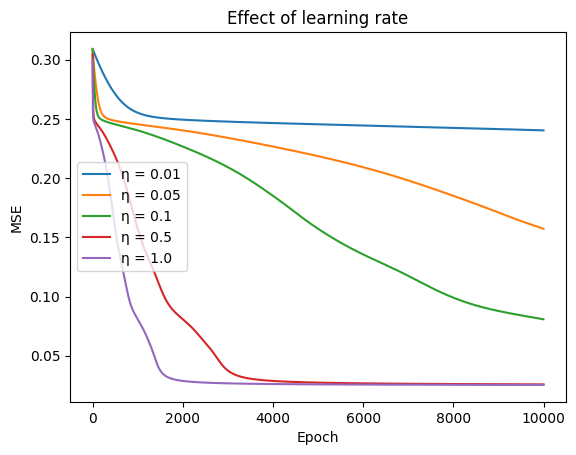

In [48]:
plt.figure()

for learning_rate in learning_rates:
    results = learning_rate_results[learning_rate]
    mean_mse = np.mean([network["mse_history"] for network in results], axis=0)
    plt.plot(mean_mse, label=f"η = {learning_rate}")

plt.xlabel("Epoch")
plt.ylabel("MSE")
plt.title("Effect of learning rate")
plt.legend()

plt.show()

Different initialization weights

In [46]:
def initialize_weights_small(rng):
    return rng.standard_normal(9) * 0.1

def initialize_weights_uniform(rng):
    return rng.uniform(-1, 1, 9)

In [47]:
initialization_functions = {
    "Standard normal": initialize_weights_standard,
    "Small": initialize_weights_small,
    "Uniform": initialize_weights_uniform
}

initialization_results = {}

for initialization_name, initialization_func in initialization_functions.items():

    initialization_results[initialization_name] = []

    for seed in range(20):

        network_result = train(XOR_inputs, XOR_targets, initialization_func, sigmoid, sigmoid_derivative, learning_rate=0.1, epochs=10000, seed=seed, print_every=0)

        initialization_results[initialization_name].append(network_result)


Initialization comparison:
Standard normal | Average MSE: 0.08077167434437507 | Successful runs: 11 / 20
Small | Average MSE: 0.2499980796731327 | Successful runs: 0 / 20
Uniform | Average MSE: 0.09834367899003416 | Successful runs: 11 / 20


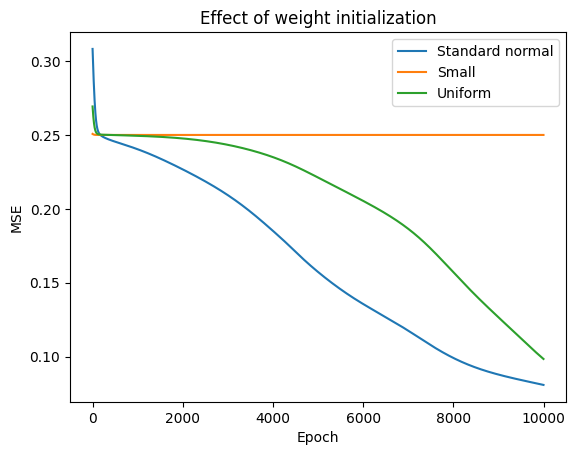

In [49]:
print("\nInitialization comparison:")


for initialization_name, results in initialization_results.items():

    final_mse = [network["mse_history"][-1] for network in results]

    final_errors = [network["misclassified_history"][-1] for network in results]

    successful_runs = sum(error == 0 for error in final_errors)

    print(initialization_name, "| Average MSE:", np.mean(final_mse), "| Successful runs:", successful_runs, "/", len(results))

plt.figure()

for initialization_name in initialization_results:

    results = initialization_results[initialization_name]

    mean_mse = np.mean([network["mse_history"] for network in results], axis=0)

    plt.plot(mean_mse, label=initialization_name)

plt.xlabel("Epoch")
plt.ylabel("MSE")
plt.title("Effect of weight initialization")
plt.legend()

plt.show()


Different Activation functions

In [40]:
def tanh(x):
    return np.tanh(x)


def tanh_derivative(x):
    return 1 - np.tanh(x) ** 2


def relu(x):
    return np.maximum(0, x)


def relu_derivative(x):
    return (x > 0).astype(float)

activation_functions = {
    "Sigmoid": (sigmoid, sigmoid_derivative),
    "Tanh": (tanh, tanh_derivative),
    "ReLU": (relu, relu_derivative)
}

activation_results = {}
seeds = range(20)

for activation_name, (activation_func, activation_derivative) in activation_functions.items():
    activation_results[activation_name] = []
    for seed in seeds:
        network_result = train(XOR_inputs, XOR_targets, initialize_weights_standard, activation_func, activation_derivative, learning_rate=0.1, epochs=10000, seed=seed, print_every=0)
        activation_results[activation_name].append(network_result)


In [41]:



print("\nActivation function comparison:")

for activation_name in activation_functions:

    results = activation_results[activation_name]
    final_mse = [network["mse_history"][-1] for network in results]
    final_errors = [network["misclassified_history"][-1] for network in results]
    successful_runs = sum(error == 0 for error in final_errors)
    print(activation_name, "| Average MSE:", np.mean(final_mse), "| Successful runs:", successful_runs, "/", len(results))



Activation function comparison:
Sigmoid | Average MSE: 0.08077167434437507 | Successful runs: 11 / 20
Tanh | Average MSE: 0.07006919473293428 | Successful runs: 9 / 20
ReLU | Average MSE: 0.11283077109186905 | Successful runs: 9 / 20


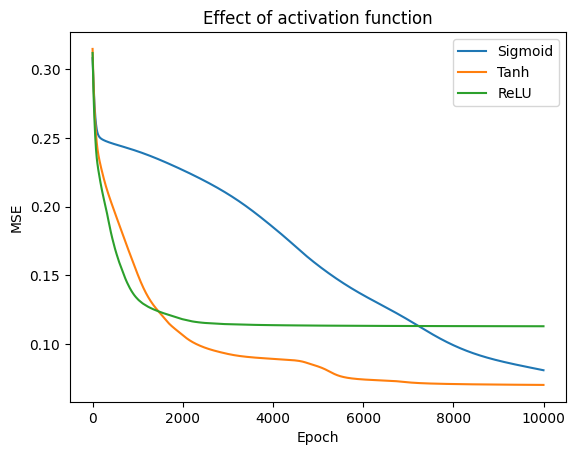

In [42]:
plt.figure()

for activation_name in activation_functions:
    results = activation_results[activation_name]
    mean_mse = np.mean([network["mse_history"] for network in results], axis=0)
    plt.plot(mean_mse, label=activation_name)

plt.xlabel("Epoch")
plt.ylabel("MSE")
plt.title("Effect of activation function")
plt.legend()
plt.show()

Lazy random weight approach

In [43]:
def lazy_search(rng, lower=-5, upper=5):

    attempts = 0
    while True:
        attempts += 1
        w = rng.uniform(lower, upper, 9)
        predictions = get_predictions(w, XOR_inputs, sigmoid, sigmoid)
        predicted_labels = (predictions >= 0.5).astype(int)

        if np.array_equal(predicted_labels, XOR_targets):
            return w, attempts

lazy_attempts = []
lazy_networks = []

for seed in range(20):
    rng = np.random.default_rng(seed)
    weights, attempts = lazy_search(rng)
    lazy_attempts.append(attempts)
    lazy_networks.append(weights)
    print("Lazy run:", seed + 1, "| Attempts:", attempts)

Lazy run: 1 | Attempts: 84
Lazy run: 2 | Attempts: 3271
Lazy run: 3 | Attempts: 10588
Lazy run: 4 | Attempts: 525
Lazy run: 5 | Attempts: 1383
Lazy run: 6 | Attempts: 76
Lazy run: 7 | Attempts: 3698
Lazy run: 8 | Attempts: 1921
Lazy run: 9 | Attempts: 590
Lazy run: 10 | Attempts: 1295
Lazy run: 11 | Attempts: 605
Lazy run: 12 | Attempts: 191
Lazy run: 13 | Attempts: 717
Lazy run: 14 | Attempts: 2968
Lazy run: 15 | Attempts: 5154
Lazy run: 16 | Attempts: 11068
Lazy run: 17 | Attempts: 31
Lazy run: 18 | Attempts: 1693
Lazy run: 19 | Attempts: 276
Lazy run: 20 | Attempts: 3520



Lazy approach results:
Mean attempts: 2482.7
Median attempts: 1339.0
Minimum attempts: 31
Maximum attempts: 11068


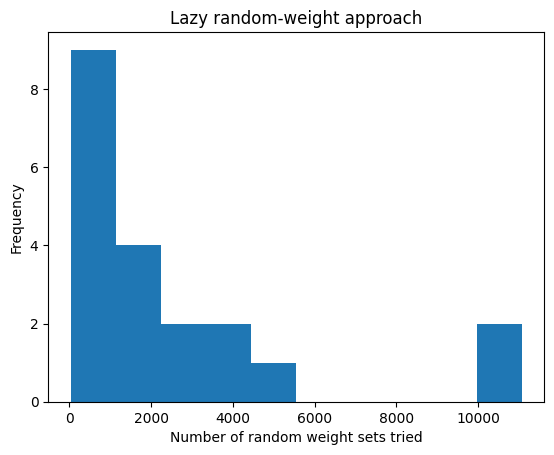

In [44]:
print("\nLazy approach results:")
print("Mean attempts:", np.mean(lazy_attempts))
print("Median attempts:", np.median(lazy_attempts))
print("Minimum attempts:", np.min(lazy_attempts))
print("Maximum attempts:", np.max(lazy_attempts))

plt.figure()
plt.hist(lazy_attempts, bins=10)

plt.xlabel("Number of random weight sets tried")
plt.ylabel("Frequency")
plt.title("Lazy random-weight approach")

plt.show()

Final results

In [ ]:
print("\nFinal trained network:")

print("Weights:")
print(network["weights"])

print("\nPredictions:")
print(network["final_predictions"])

print("\nClasses:")
print((network["final_predictions"] >= 0.5).astype(int))

print("\nMSE:")
print(network["mse_history"][-1])

print("\nMisclassified:")
print(network["misclassified_history"][-1])